# 4. Continuous Density Transport Analysis

In this section, we will delve into the details of continuous density transport analysis. This analysis uniquely integrates the three learned parameters of the PDE and simulate the process a cell destribution its cell mass to its progenies. 

This notebook includes:
- simulating cell state transition trajectory
- conducting continuous density transport analysis
- visulizing the transportation matrix
- visulizing the redistributed density with sankey diagram

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
if sys.platform.startswith("darwin"):
    os.environ['KMP_DUPLICATE_LIB_OK']='True'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc
sc.settings.set_figure_params(frameon=False, dpi=30)

import pseudodynamics as pdp
os.chdir(pdp.main_dir)
print("workding directory changed to:", pdp.main_dir)

/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment

workding directory changed to: /rds/user/wz369/hpc-work/pseudodynamics_plus


## Exp configs

We provide a simple example of how to use the functions in the package. Again, both the model and the data are resumed from the provided config file.

In [33]:
# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled_n6/pde_params_tsense"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

Reload experimental config and the model

In [41]:

config = pdp.ExperimentConfig(os.path.abspath(os.path.join(config_dir, 'V2_config.json')))
config.from_json(os.path.abspath(os.path.join(config_dir, 'V2_config.json')))



ckpt = config.find_lastest_ckpt()
pde_model = pdp.models.pde_params.load_from_checkpoint(ckpt, map_location='cpu')

result_dir = config.experiment_config['save_dir'].replace("logs", "results")
result_dir = result_dir + f"_2"
config.result_dir = result_dir
pdp.tl.make_dir(result_dir)

/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.5.1.post0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


## Tissue flow of megakaryocyte and erythrocyte differentiation   


Here in this notebook we will simulate the tissue flow of megakaryocyte and erythrocyte differentiation. A ideal and simple branching system that can demonstrate the continuous density transport.

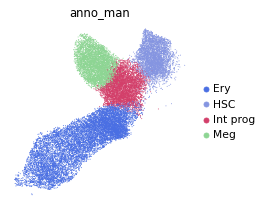

In [ ]:
# # load dataset
dataset_name = config.experiment_config['dataset']
print(dataset_name)
adata = sc.read_h5ad(f'data/{dataset_name}.h5ad')

sc.pl.umap(adata, color='anno_man')

In [ ]:
# create the pseudydynamics+ datamodule 
ds_config = config.dataset_config.copy()
timepoint_idx = ds_config['timepoint_idx'].copy()
ds_config['timepoint_idx'] = None
ds_config['knn_volume'] = eval(config.raw_args['knn_volume'])

full_DS = pdp.reader.TwoTimpepoint_AnnDS(adata,split=None,**ds_config)
cellstate_key = config.dataset_config['cellstate_key']


Dataset : Computing density :
	 `density_funs` not specified, default estimator gaussian kde
Dataset : all cells are used


## simulate trajectory for HSC 


The learned drift term (differentiation rate) captures the next moment chagnes of cell state values in every dimension. This can be used to simulate the trajectory of cell state values. Here we start from the HSC and 

In [37]:
# go for all HSC cells
import torch 
import gc
import torch.nn.functional as F
from pseudodynamics.models import Density_Transfer
from tqdm.auto import tqdm


In [ ]:
# Density Transfer Class wrapping the PDE model
DT = Density_Transfer(pde_model)

In [ ]:
# prepare the initial cell states
HSC_ad = adata[adata.obs['anno_man']=='HSC'].copy()
s0 = HSC_ad.obsm['DM_EigenVectors_multiscaled']
s0 = torch.from_numpy(s0).float()

# the simulating time window, let say day 12 to day 49
integrate_time = np.linspace(12, 49 , 11) / pde_model.time_scale_factor

In [ ]:
S_trajectory = DT.cellstate_drift(s0, integrate_time)
print(S_trajectory.shape)

(10, 67, 3)


The simualted trajectory records the intermediate states of the cell state transition process.

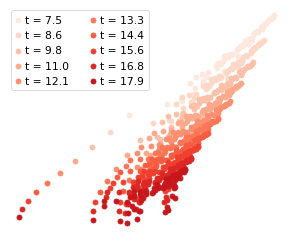

In [72]:
color_fn = lambda x : plt.colormaps.get_cmap('Reds')((x+1)/13)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)
ax.axis("off")

for step in range(S_trajectory.shape[0]): # the number of time steps

    ax.scatter(S_trajectory[step,:,0], S_trajectory[step,:,1],
                color = color_fn(step), 
                label = f't = {integrate_time[step]:.1f}'
                )
    ax.legend(ncol=2)


## Dynamic density transport

In [38]:
n_interval = 10
n_cell = 300
celltype_key = 'anno_man'
start_celltype = 'HSC'
device = 'cpu'
save_name = 'ery_mk_density_transport'

Instanize the DensityTransport class with pde model

In [73]:
result_dir = config.result_dir
pdp.tl.make_dir(os.path.join(result_dir, save_name))

# timepoint key
selected_time = [ 3,   7,  12,  27,  49, 112, 269] 

timepoint_key = 'timepoint_tx_days'
t0 = selected_time[0]
scaling_factor = pde_model.time_scale_factor

In [85]:
pdp.tl.make_dir(os.path.join(result_dir, save_name))

In [ ]:
HSC_cbs = []


for it,t in tqdm(enumerate(selected_time[:-1])):
    
    # CHANGE HERE to adjust the integration time according to how the time is normalized
    t1 = t - t0
    t2 = selected_time[it+1] - t0
    integrate_time = np.linspace(t1, t2 ,n_interval+1) / pde_model.time_scale_factor
    
    # print out the integration time
    print(np.round(integrate_time, 2))

    # find cell of time
    start_cell = adata.obs.query(f"`{celltype_key}` == @start_celltype & `{timepoint_key}` == @t").index
    start_cell = list(start_cell)
    HSC_cbs.append(start_cell)

    # define initital density and cellstates
    cell_index = [np.where(adata.obs_names == x)[0].item() for x in start_cell]
    u0 = full_DS.u_b[it, cell_index].float().to(device)
    s0 = torch.from_numpy(full_DS.cellstate[cell_index]).float().to(device)

    # density transport here
    S_trajectory = DT.cellstate_drift(s0, integrate_time)
    Tmaps_t, Tmaps_t_norm = DT.transition_by_batch(s0, u0,integrate_time,
                                                    n_interval=n_interval, 
                                                    ncell=n_cell)

    del u0, s0


    print(f"results saved to {result_dir}")
    endtime = np.round(integrate_time, 2)[-1]
    np.save(os.path.join(result_dir, save_name, f"{start_celltype}_Day{t1}-{t2}_sim_trajectory.npy"), S_trajectory)
    np.save(os.path.join(result_dir, save_name, f"{start_celltype}_Day{t1}-{t2}_TransportMap.npy"), Tmaps_t)
    np.save(os.path.join(result_dir, save_name, f"{start_celltype}_Day{t1}-{t2}_Norm_TransportMap.npy"), Tmaps_t_norm)
    np.save(os.path.join(result_dir, save_name, f"{start_celltype}_Day{t1}-{t2}_cellbarcode.npy"), start_cell)


0it [00:00, ?it/s]

[0.  0.4 0.8 1.2 1.6 2.  2.4 2.8 3.2 3.6 4. ]
results saved to /rds/user/wz369/hpc-work/pseudodynamics_plus/results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2
[4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9. ]
results saved to /rds/user/wz369/hpc-work/pseudodynamics_plus/results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2
[ 9.  10.5 12.  13.5 15.  16.5 18.  19.5 21.  22.5 24. ]
results saved to /rds/user/wz369/hpc-work/pseudodynamics_plus/results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2
[24.  26.2 28.4 30.6 32.8 35.  37.2 39.4 41.6 43.8 46. ]
results saved to /rds/user/wz369/hpc-work/pseudodynamics_plus/results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2
[ 46.   52.3  58.6  64.9  71.2  77.5  83.8  90.1  96.4 102.7 109. ]
results saved to /rds/user/wz369/hpc-work/pseudodynamics_plus/results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2
[109.  124.7 140.4 156.1 171.8 187.5 203.2 218.9 234.6 250.3 266. ]
results saved to /rds/user/wz369/hpc-work/pseudodynamics_plus/results/ery

## Analysing the density transport result

In [ ]:
# load the DT results
DTA = pdp.models.DT_analysis(adata, result_dir=os.path.join(result_dir, save_name), celltype=start_celltype)

# annotate the celltype for simulated data point
celltype_trajectory = DTA.annotate_trajectory('DM_EigenVectors_multiscaled', obs_key='anno_man', copy=False)

24-46 (11, 386, 3)
46-109 (11, 281, 3)
4-9 (11, 130, 3)
0-4 (11, 105, 3)
9-24 (11, 67, 3)
109-266 (11, 704, 3)


### visualizing the tranpsport matrix

Text(0.5, 1.0, '9-24')

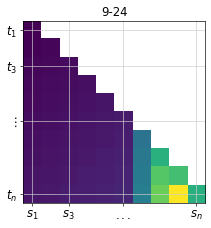

In [96]:
time_span = '9-24'

ax = DTA.vis_Tmap(DTA.TM_dict[time_span][3])
ax.set_title(time_span)

### visualizing the cell type redistribution

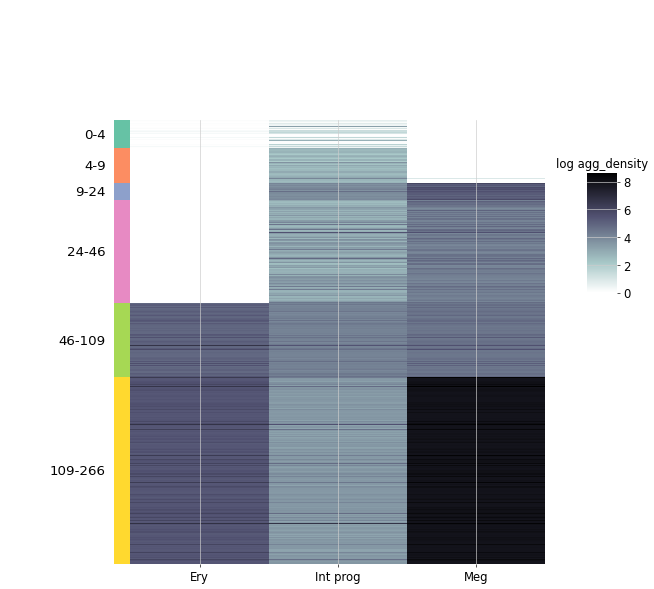

In [ ]:
DTA.density_by_celltype_step(celltypes=['Ery', 'Int prog', 'Meg'], step=-1, norm=True)
g = DTA.heatmap_cell_proportions(
                                ['Ery', 'Int prog', 'Meg'],
                                value='agg_density',
                                step=-2,
                                log_normalize = True,
                                    cbar_pos=[0.99, 0.5, 0.05,0.2],
                                    cmap='bone_r'
                                     )

## Sankey plot for tissue level flow

In [ ]:
celltypes = ["Ery",  "Meg", "Int prog"]
first_step= DTA.density_by_celltype_step(celltypes=celltypes, step=0, norm=False)
last_step= DTA.density_by_celltype_step(celltypes=celltypes, step=-1, norm=False)


first_step_sum = first_step.groupby('Day').agg("mean").reset_index()
first_step_sum['step'] = 1
first_step_sum.rename({'Int prog':"MEP"}, axis=1, inplace=True)
first_step_sum = first_step_sum.set_index("Day").rename({'Int prog':"MEP"},axis=1)

last_step_sum = last_step.groupby('Day').agg("mean").reset_index()
last_step_sum['step'] = 10
last_step_sum = last_step_sum.set_index("Day").rename({'Int prog':"MEP"},axis=1)

first_step_sum

,Ery,Meg,MEP,step
Day,,,,
0-4,0.000000,0.000000e+00,4.035307e-07,1
109-266,0.000002,9.566587e-03,1.072948e-05,1
24-46,0.000000,3.130689e-06,1.040727e-04,1
4-9,0.000000,0.000000e+00,1.541898e-06,1
46-109,0.000000,1.909346e-04,1.470297e-03,1
9-24,0.000000,1.205958e-07,7.007235e-05,1


### visualize sankey plot

In [ ]:
!pip install plotly
!pip install Kaleido

In [117]:
import pandas as pd
import plotly.graph_objects as go

In [ ]:
timeponts = ['0-4', '4-9', '9-24', '24-46', '46-109']
celltypes = ["MEP", "Ery",  "Meg"]

label = []
for i, time in enumerate(adata.uns['pop']['t'][:6]):
    for s, source_cell in enumerate(celltypes):
        label.append(f'{source_cell} D{time}')

color = ['#7f7f7f', '#8C554A',  '#AFC7E5'] * 6

source = []
target = []
value = []
for i, time in enumerate(timeponts):
    for t, target_cell in enumerate(celltypes):
        for s, source_cell in enumerate(celltypes):
        
            
            source.append(i*3 + s)
            target.append((i+1)*3 + t)

            if source_cell == 'MEP':
                prop = last_step_sum.loc[time, target_cell].item() / last_step_sum.loc[time, celltypes].sum().item()
                flow = last_step_sum.loc[time][target_cell] - first_step_sum.loc[time][source_cell] * prop
                # flow = first_step_sum.loc[time][target_cell] * prop #- first_step_sum.loc[time][source_cell] * prop
                value.append(flow)
                
            elif source_cell == target_cell:
                value.append(1e-20)
            
            else:
                value.append(0)

In [121]:
flow_df = pd.DataFrame(
    np.array([source, target, value]).T,
    columns=['source', 'target', 'value']
)

y_loc = []
x_loc = [] 
for i in range(6):
    pad = (i + 1)* 0.1
    y_loc.extend(
        [0.6-np.random.random()*0.1, 0.6-pad, 0.6+pad]
    )
    x_loc.extend(
        [i*0.2, i*0.2, i*0.2]
    )

In [124]:
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = label,
      color = color,
      x = x_loc,
      y = y_loc,
      
    ),
    link = dict(
      source = source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = target,
      value = value
  ))])

fig.update_layout(font_size=16)
fig.show()

In [ ]:
fig.write_image(os.path.join(result_dir, 'unnormalized_sankey.svg'))